# Michaelis-Menten & Hill Kinetics

This is the first of three notebooks that build up the ingredients needed to understand the phenomena

- steady state
- multiple steady states
- oscillations

in simple enzymatic reaction networks.

This session starts with the basics: the Michaelis-Menten (MM) equation and its generalisation, the Hill equation. Both describe the reaction of a substrate, denoted $S$, as it is converted to a product$P$ under the action of an enzyme.
These are two closely related considered as **rate laws** for an enzymatic reaction *in vitro*. 

If we take such a rate law in isolation, the assumption is that the reaction operates in a closed system, with no inflow or outflow of substrate or product. Typically we start with some concentration of $S$ and the enzyme $E$ with initially no product$P$ in a closed container and expect the equation to describe the rate with which the reaction proceeds. As a *rate law* we want to see the rate as a function of the substrate concentration. Such a mathematical equation thus makes the description of the process quantitative.


MM kinetics is nonlinear but monotonic — the reaction rate rises smoothly towards a maximum ($V_{max}$) as substrate concentration increases. 

**This notebook:** hands-on understanding of the Michaelis-Menten and Hill rate laws — where they come from, what their parameters mean, and how the so-called Hill coefficient $n$ controls the shape of the function. Mathematically, it controls the transition from hyperbolic to switch-like (sigmoidal) behaviour. Importantly, this mathematical transition will lead to different types of dynamics under open flow conditions, where we assume to have an exchange of substrate and product with the environment. This will be our basic model of an enzymatic reaction *in vivo".

In later sessions, we will use such rate laws as building blocks to contruct more complicated networks of reactions.


## Motivation: How Rate Equations Are Useful

In biological systems, the rate of a chemical reaction or a receptor-binding event is rarely a simple linear function of the concentration of a molecule. Instead, it rises steeply at first and then plateaus (saturates), because the enzyme or receptor has a finite number of binding sites.

A simple, interpretable rate law captures three key features:

- **Saturation**: rate $\to V_{max}$ at high substrate/ligand concentration.
- **Cooperative effects**, where binding of one molecule makes subsequent binding easier or harder.
- **Half-maximal points** (e.g. $K_m$ for enzymes, $EC_{50}$ or $K_d$ for receptors).

Without such an equation, one would need to simulate every individual binding step (an ODE for each intermediate complex), which quickly becomes impractical. MM and Hill kinetics are reduced-order models: they hide microscopic complexity behind a handful of phenomenological parameters.

## Historical Background

**Early 20th century — enzyme kinetics.**

- **1903**: Victor Henri observed that enzyme reaction rates saturate, and proposed an equation involving an intermediate enzyme-substrate complex.
- **1913**: Leonor Michaelis and Maud Menten (a German biochemist and a Canadian physician/biochemist) re-derived and experimentally validated the equation

$$v = \frac{V_{max}[S]}{K_m+[S]}$$

They assumed that substrate binding is at fast equilibrium compared to the catalytic step. This explains why the rate is linear at low $[S]$ (first order) and constant at high $[S]$ (zero order).

## The generalisation — cooperativity

In **1910**, Archibald V. Hill, while studying oxygen binding to haemoglobin (which has four subunits), noticed that the binding curve was steeper than a Michaelis-Menten curve — non-hyperbolic and sigmoidal. He proposed an empirical equation:

$$\theta = \frac{[L]^n}{K_d^{\,n} + [L]^n}$$

where $\theta$ is the fractional occupancy, $[L]$ is the ligand concentration, $n$ is the **Hill coefficient**, and $K_d$ is the dissociation constant (often written as $EC_{50}$).

**Why $n=1$ is special:** when $n=1$, the Hill equation reduces exactly to the Michaelis-Menten form. This describes non-cooperative binding — each site acts independently. For enzymes, $n=1$ means the Michaelis-Menten equation applies.

The Hill equation, with cooperativity exponent $n>1$, introduces a genuinely new qualitative feature: an inflection point, where the rate curve switches from concave-up to concave-down. For large $n$, the curve becomes sigmoidal, approaching a step function between an "off" and an "on" state.

This single parameter, $n$, is a first example of how a smooth change in a model parameter can produce a *qualitative* change in behaviour — a theme that runs through the whole notebook series. In notebook 02, a Hill-type rate law with an additional inhibitory term is embedded in an open-flow system, where this nonlinearity, combined with continuous in- and outflow, can create multiple stable steady states (bistability). In notebook 03, adding a delayed feedback loop to the same kind of nonlinear kinetics turns these steady states into sustained oscillations.

**Interpretation of $n$:**

- $n>1$: positive cooperativity (e.g. haemoglobin — binding the first $O_2$ increases the affinity for the next).
- $n<1$: negative cooperativity (rarer; binding the first ligand reduces affinity).

Note that $n$ is usually *not* equal to the number of binding sites — it is an empirical measure of the steepness of the binding curve.

## Use in computational modelling

Today, these equations are embedded in almost all multi-scale models of biological networks. Four concrete examples:

**1. Whole-cell and signalling-pathway models (ODE-based).** In systems biology (e.g. modelling the MAPK/ERK pathway, calcium dynamics, or gene regulation), simulating thousands of individual reactions is impractical. Instead, an enzyme-catalysed reaction is written directly as a contribution to a rate equation, $\frac{dP}{dt}=\frac{V_{max}\cdot S}{K_m + S}$, without an explicit enzyme-substrate complex; and a transcription factor binding cooperatively to a promoter is written as $\frac{d\,\text{mRNA}}{dt} = \frac{\beta \cdot [TF]^n}{K_{d}^{n} + [TF]^n}$. Tools such as COPASI, SBML-compatible solvers, or MATLAB's SimBiology rely heavily on this kind of reduction.

**2. Pharmacokinetics/pharmacodynamics (PK/PD).** To model a drug-receptor interaction *in vivo*, the Hill equation — often called the *Emax model* in pharmacology — predicts the effect $E$ from the drug concentration $C$:

$$E = E_0 + \frac{E_{max}\cdot C^n }{EC_{50}^{n} + C^n}$$

For a new drug, $EC_{50}$ and $n$ are fitted from dose-response data. If $n>1$, small increases in dose cause disproportionately large jumps in effect (a steep response) — an important consideration for safety margins.

**3. Parameter reduction in computational neuroscience.** When modelling synaptic transmission or ion channels, the rate of neurotransmitter release as a function of calcium concentration is often described by a Hill equation with $n\approx4$ (reflecting cooperative $Ca^{2+}$ binding to synaptotagmin). This reduces a multi-step $Ca^{2+}$-binding cascade to a single equation, making large network models (e.g. thousand-neuron circuits) computationally tractable.

**4. Model inference and fitting.** In single-cell RNA-seq or proteomics, the Hill equation is used as a transfer function between a regulator's concentration and a target gene's expression. Bayesian inference or nonlinear least squares can then estimate $n$, $EC_{50}$, and $V_{max}$ from noisy data — revealing whether a regulatory step is switch-like ($n\gg1$).

## A caution for modelling

The Hill equation is empirically derived and, for $n>1$, thermodynamically inconsistent if derived from a simple mass-action binding scheme (the exception being $n=1$). For genuinely mechanistic models of multi-step binding, the Adair equation or the MWC (Monod-Wyman-Changeux) model are more appropriate. Nevertheless, the Hill equation's simplicity and good empirical fit to many cooperative systems make it the workhorse of applied modelling — and the starting point for this notebook series.

| Feature | Michaelis-Menten ($n=1$) | Hill ($n \neq 1$) |
|---|---|---|
| Curve shape | Hyperbolic | Sigmoidal (if $n>1$) |
| Biological meaning | Non-cooperative enzyme / receptor | Cooperative binding |
| Key parameter(s) | $K_m$ (affinity for substrate) | $EC_{50}$ and $n$ (steepness) |
| Modern use | Metabolic networks, single-substrate enzymes | Drug dose-response, gene regulation, ion channels |

In this session, we look at the rate law in isolation, as a static function describing rate as a function of substrate concentration. In notebooks 02 and 03 this and related rate laws are used as components of a dynamical model of enzymatic reactions in open environments such as cells and tissues.

# Illustration of the Nonlinear Function
## Imports

In [7]:
# figure: matplotlib's figure constructor, used to build multi-panel plots
from matplotlib.pyplot import figure

# LinearSegmentedColormap: build a custom colour gradient (used below to
# colour-code curves by their Hill coefficient n)
from matplotlib.colors import LinearSegmentedColormap

# Numpy Library
import numpy as np

## Rate function definition


First we specify the substrate concentration or concentration range and two constants needed to evaluate the *Michaelis-Menten* function. The function call will return a range of velocities corresponding to the specified substrate concentration range. 

In [8]:
def michaelis_menten_kinetics(S, k_max, K_m):
    """
    Hill kinetics equation; reduces to Michaelis-Menten for n=1
    
    S:     substrate concentration (typically a range of values expected)
    k_max: maximum reaction rate (includes enzyme concentration)
    K_m:   Michaelis constant
    """

    rate = k_max * S / (K_m + S)
    
    return rate


## Plot of the Michaelis-Menten Rate Function

The mathematical expression for a rate given by the Michaelis-Menten law as specified in the above function is:

$$v = \frac{k_{max}[S]}{K_m+[S]}$$

The function can be evaluated computationally if the two constants are assigned values and if a range of susbtrate concentrations if provided.


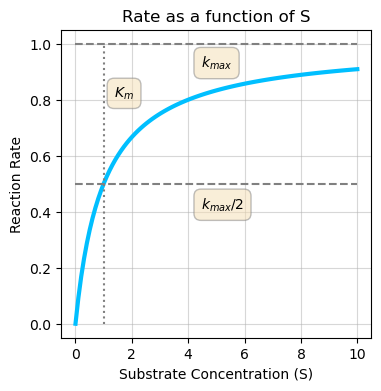

In [9]:
# Constants
K_m   = 1
k_max = 1

# Range of substrate values
S_min, S_max = 0, 10
values = 100
S_vals = np.linspace(S_min, S_max, values)

# Calculation of the rate for all values of S
rate = michaelis_menten_kinetics(S_vals, k_max, K_m)


# --- Plot 1: line plots of fucntion ---
fig = figure(figsize=(4, 4))

ax1 = fig.add_subplot()

ax1.plot(S_vals, rate, color='deepskyblue', linewidth=3)
ax1.vlines(K_m, 0, k_max, 'gray', linestyles='dotted')
ax1.hlines(k_max/2, 0, S_max, 'gray', linestyles='dashed')
ax1.hlines(k_max, 0, S_max, 'gray', linestyles='dashed')

ax1.set_xlabel('Substrate Concentration (S)')
ax1.set_ylabel('Reaction Rate')
ax1.set_title('Rate as a function of S')
ax1.grid(True, alpha=0.5)


# Textbox 1
textstr = "$K_m$"

# Define the style of the textbox using a dictionary
props = dict(
    boxstyle='round,pad=0.5', 
    facecolor='wheat', 
    alpha=0.5, 
    edgecolor='gray'
)

# Place the text box in the upper left of the axes
ax1.text(
    0.17, 0.82, textstr, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=props
)

# Textbox 2
textstr = "$k_{max} / 2$"

# Define the style of the textbox using a dictionary
props = dict(
    boxstyle='round,pad=0.5', 
    facecolor='wheat', 
    alpha=0.5, 
    edgecolor='gray'
)

# Place the text box in the upper left of the axes
ax1.text(
    0.45, 0.46, textstr, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=props
);

# Textbox 3
textstr = "$k_{max}$"

# Define the style of the textbox using a dictionary
props = dict(
    boxstyle='round,pad=0.5', 
    facecolor='wheat', 
    alpha=0.5, 
    edgecolor='gray'
)

# Place the text box in the upper left of the axes
ax1.text(
    0.45, 0.92, textstr, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=props
);

The rate (blue curve) increase with substrate concentration. However, it is not a straight line. The increase (e.g. per unit of substrate concentration) becomes less and less. If you modify the range of substrate concentration, you can see that the function plateaus at 10. This is the value of $k_max$, the maximal rate. 

The empirical rate constant $k_max$ formally combines (multiplies) the speed at which the enzyme converts the substrate with the enzyme concentration present. Thus an increase in enzyme concentration would be expressed as an increase in  $k_max$.

$K_m$: the vertical line is the point where the substrate concentration is equal to the value of $K_m$. $K_m$ thus has the units of concentration (e.g. mol/litre). When the substrate concentration is equal to the parameter $K_m$, the rate if half of the maximum rate. This is shown by the horizontal line. 

Now we will define and plot the more flexible Hill function. We can essentially use the code from above to plot it.

In [10]:
def hill_kinetics(S, k_max, K_m, n):
    """
    Hill kinetics equation; reduces to Michaelis-Menten for n=1
    
    S:     substrate concentration (typically a range of values expected)
    k_max: maximum reaction rate (includes enzyme concentration)
    K_m:   Michaelis constant (fixed at 1)
    n:     Hill coefficient (exponent of cooperativity, positive real number)
    """

    rate = (k_max * S**n) / (K_m**n + S**n)
    
    return rate


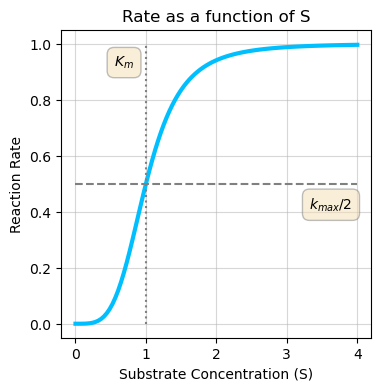

In [11]:
# Constants
K_m   = 1
k_max = 1
n     = 4    # Hill coefficient 

# Range of substrate values
S_min, S_max = 0, 4
values = 100
S_vals = np.linspace(S_min, S_max, values)

# Calculation of the rate for all values of S
rate = hill_kinetics(S_vals, k_max, K_m, n)


# --- Plot 1: line plots of fucntion ---
fig = figure(figsize=(4, 4))

ax1 = fig.add_subplot()

ax1.plot(S_vals, rate, color='deepskyblue', linewidth=3)
ax1.vlines(1, 0, k_max, 'gray', linestyles='dotted')
ax1.hlines(k_max/2, 0, S_max, 'gray', linestyles='dashed')

ax1.set_xlabel('Substrate Concentration (S)')
ax1.set_ylabel('Reaction Rate')
ax1.set_title('Rate as a function of S')
ax1.grid(True, alpha=0.5)


# Textbox 1
textstr = "$K_m$"

# Define the style of the textbox using a dictionary
props = dict(
    boxstyle='round,pad=0.5', 
    facecolor='wheat', 
    alpha=0.5, 
    edgecolor='gray'
)

# Place the text box in the upper left of the axes
ax1.text(
    0.17, 0.92, textstr, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=props
)

# Textbox 2
textstr = "$k_{max} / 2$"

# Define the style of the textbox using a dictionary
props = dict(
    boxstyle='round,pad=0.5', 
    facecolor='wheat', 
    alpha=0.5, 
    edgecolor='gray'
)

# Place the text box in the upper left of the axes
ax1.text(
    0.8, 0.46, textstr, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=props
);

This plot again shows the rate as a function of $S$. The introduction of the Hill exponent changes the shape. For the chosen value, we see a sigmoidal rate law. Note that the vertical and horizontal line at $K_m$ and $k_max / 2$ cross at the point where the curvature changes from positive to negative. This is called an inflection points. 

The close relationship between the Michaelis-menten and the Hill equation is that for $n=1$ they are identical. The introductio of the Hill ceofficient $n$ thus allows for greater flexibility to describe empirical rate laws. 

Here is some more elaborated code to demonstrate the scope of this flexibility. 

## Call of the rate function and plot


Enzyme Kinetics without and with cooperativity
Parameters: k_max = 1, K_m = 1

Key observations:
1. n = 1: Classic hyperbolic Michaelis-Menten kinetics
2. n > 1: Positive cooperativity - sigmoidal curves
3. n >> 1: Switch-like behavior - very steep transition
5. Half-maximal rate at S = K_m = 1

 Change from hyperbolic (blue) to switch-like shape (orange, red)
 


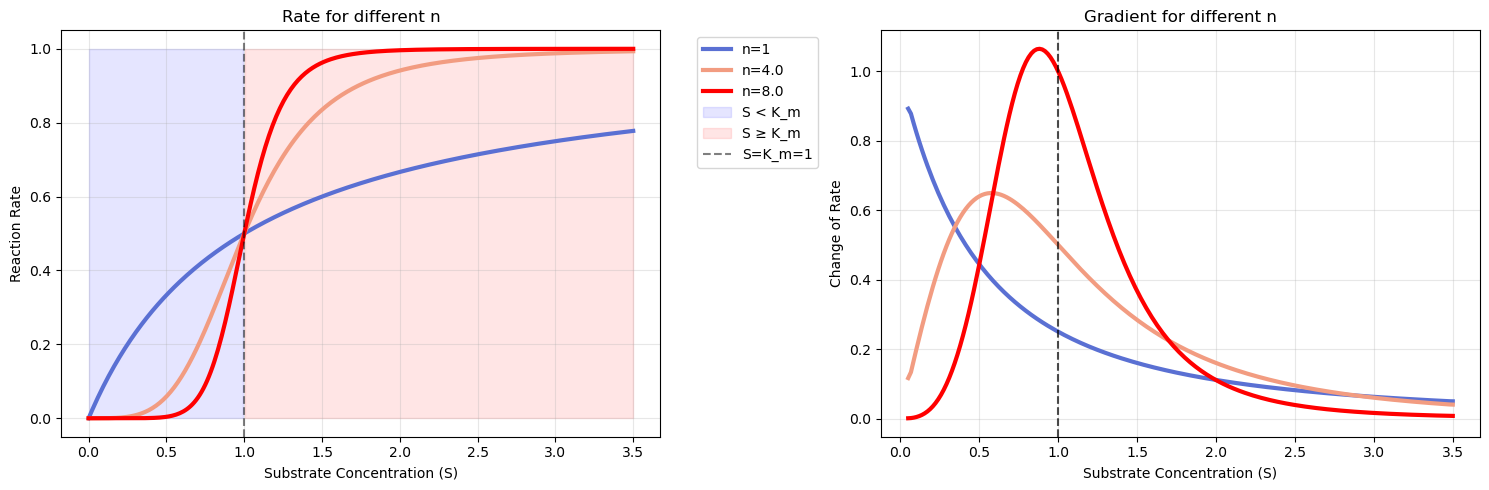

In [15]:
# Fixed parameters for the rate law: K_m sets the half-maximal substrate
# concentration, k_max sets the maximal rate. Here, both are set to 1 for simplicity,
# so that S is naturally measured in units of K_m).
K_m   = 1
k_max = 1

# Shared colormap: royalblue -> lightsalmon -> red over the full n range.
# This lets every plot below use a consistent colour for a given Hill
# coefficient n, making it easy to compare curves across figures.
_cmap = LinearSegmentedColormap.from_list('hill', ['royalblue', 'lightsalmon', 'red'])

def n_to_color(n, n_min=0.5, n_max=8.0):
    """Return (r, g, b) floats in [0,1] for a given Hill coefficient n."""
    t = float((n - n_min) / (n_max - n_min))
    return _cmap(t)[:3]

def n_to_plotly_color(n, n_min=0.5, n_max=8.0):
    """Same colour mapping as n_to_color, formatted as a Plotly rgb() string."""
    r, g, b = n_to_color(n, n_min, n_max)
    return f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'

# Ranges for substrate concentration S and Hill coefficient n, used below
# to build the 2D rate "landscape" (Plot 2) as well as for reference.
S_values = np.linspace(0,   3, 100)
n_values = np.linspace(0.5, 4, 100)

# Meshgrid of S and n: S and N have the same shape, so that
# hill_kinetics(S, k_max, K_m, n) can be evaluated for every
# (S, n) combination at once.
S, N = np.meshgrid(S_values, n_values)

# Evaluate the reaction rate over the whole (S, n) grid, then take the
# numerical gradient (used later to plot how steeply the rate changes).
rate_landscape = np.zeros_like(S)
for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        rate_landscape[i,j] = hill_kinetics(S[i,j], k_max, K_m, N[i,j])

rate_landscape_gradient = np.gradient(rate_landscape)


# --- Plot 1: line plots for a few representative values of n ---
fig = figure(figsize=(15, 5))

# 1. Impact of cooperativity on reaction rate
ax1 = fig.add_subplot(1, 2, 1)

S_fine = np.linspace(0, 3.5, 300)
n_transition = [1, 4.0, 8.0]
colors = [n_to_color(n) for n in n_transition]

# Plot the rate curve rate(S) for n = 1 (Michaelis-Menten), 4, and 8,
# using the shared colour scale (blue -> red as n increases).
for n, color in zip(n_transition, colors):
    rate = hill_kinetics(S_fine, k_max, K_m, n)
    ax1.plot(S_fine, rate, color=color, linewidth=3, label=f'n={n}')

# Shade the regions S < K_m and S >= K_m, and mark S = K_m with a dashed
# line - this is the half-maximal point and (for large n) the location
# of the "switch" between low and high rate.
ax1.fill_between(S_fine, 0, 1, where=(S_fine<1),  alpha=0.1, color='blue', label='S < K_m')
ax1.fill_between(S_fine, 0, 1, where=(S_fine>=1), alpha=0.1, color='red', label='S ≥ K_m')
ax1.axvline(x=1, color='black', linestyle='--', alpha=0.5, label='S=K_m=1')

ax1.set_xlabel('Substrate Concentration (S)')
ax1.set_ylabel('Reaction Rate')
ax1.set_title('Rate for different n')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)


# 2. Impact of cooperativity on the derivative of the reaction rate.
# The derivative d(rate)/dS shows how sensitively the rate responds to a
# small change in substrate concentration - this is largest near S=K_m
# for n=1, and becomes increasingly peaked/localised as n grows.
ax2 = fig.add_subplot(1, 2, 2)

S_analysis = np.linspace(0.05, 3.5, 200)

for ind, n in enumerate([1.0, 2.0, 4.0]):
    rate = hill_kinetics(S_analysis, k_max, K_m, n)
    derivative = np.gradient(rate, S_analysis)
    ax2.plot(S_analysis, derivative, label=f'n={n}', color=colors[ind], linewidth=3)

ax2.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='S=K_m=1')
ax2.set_xlabel('Substrate Concentration (S)')
ax2.set_ylabel('Change of Rate')
ax2.set_title('Gradient for different n')
# ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()


# Print a short summary of what the plots show
print("Enzyme Kinetics without and with cooperativity")
print("=" * 50)
print(f"Parameters: k_max = {k_max}, K_m = {K_m}")
print("\nKey observations:")
print("1. n = 1: Classic hyperbolic Michaelis-Menten kinetics")
print("2. n > 1: Positive cooperativity - sigmoidal curves")
print("3. n >> 1: Switch-like behavior - very steep transition")
print(f"5. Half-maximal rate at S = K_m = {K_m}")
print("\n Change from hyperbolic (blue) to switch-like shape (orange, red)")
print(' ')

Hill coefficient represents a way of describing cooperativity, originally in enzymatic processes but now widely used in other contexts as well. The left graphs show the rate function for three different values of the Hill coefficient. When $n$ is equal to 1, there is no cooperativiy. This illustrates how the rate behaves in the absence ($n=1$) of cooperativity. It is just the Michaelis-Menten law. At high values of $n$ (e.g. the red curve), the function approaches a step function: the rate is either small (to the left of the graph) or close to its maximum (to the right). In a dynamical model this leads to something reminiscent of "switching" behaviour — a reaction following such a rate law will mostly be either slow or fast. Unlike in mechanical switches, howver, there is a smooth transition between an "off" and an "on" state.

The right graph shows the derivative (or slope) of the function on the left. Note how the blue curve (Michealis-Menten) only dimishes until it approaches zero. The change of the rate of the orange and red curve, in contrast, increases initially, goes through a maximum and only then starts to decrease towards zero. The maximal gradient is always below the dotted line at the value of $K_m$. In fact it moves continuouse from 0 when $n=1$ towards $S=K_m$ as n increases. This is a direect consequence of the switching behaviour. 

Note: the rate function (left) always approaches a rate of 1 for large substrate concentrsations, independent of the Hill coefficient. Similarly, its derivative (right) always approaches zero at large $S$.

## Two parameter view of the function

An extension of the above code lets us go from a single line which is evaluated at different values of n to a two-dimensional plane: we can evaluate the function for a range of S and a range of n simultaneously and plot the two-dimenstional result as a heat map.

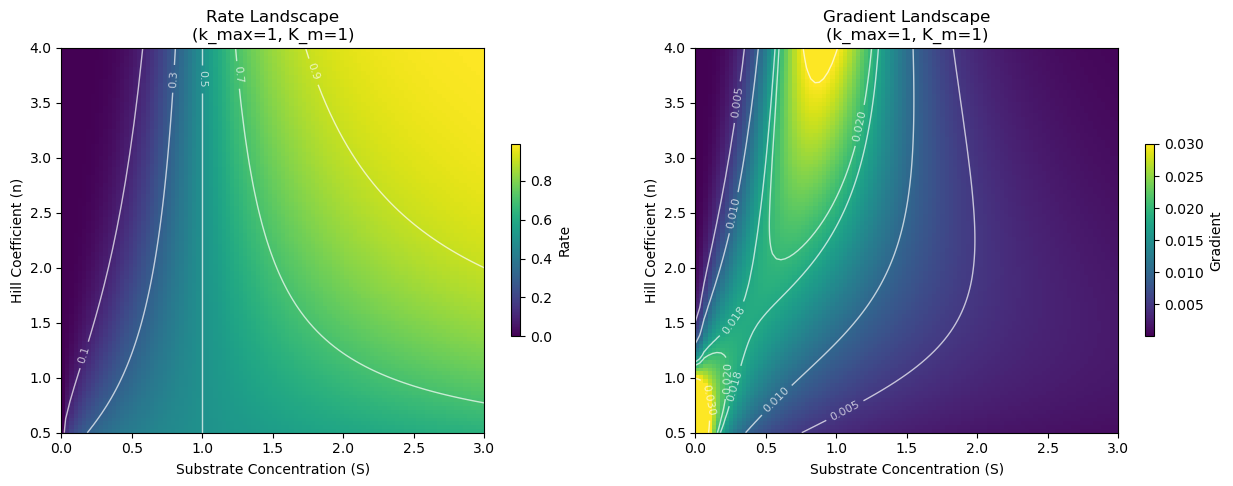

In [16]:
# --- Plot 2: 2D "landscape" view, evaluating the rate (and its gradient)
# over the full (S, n) grid computed above (rate_landscape,
# rate_landscape_gradient) ---
fig = figure(figsize=(15, 5))

# 3. Rate landscape (S vs n): colour = reaction rate for each (S, n) pair.
# The line plots in Plot 1 above correspond to horizontal slices through
# this image at fixed n.
ax3 = fig.add_subplot(1, 2, 1)

im3 = ax3.imshow(rate_landscape, extent=[S_values.min(), S_values.max(), 
                                       n_values.min(), n_values.max()],
               origin='lower', aspect='auto', cmap='viridis')
ax3.set_xlabel('Substrate Concentration (S)')
ax3.set_ylabel('Hill Coefficient (n)')
ax3.set_title(f'Rate Landscape\n(k_max={k_max}, K_m={K_m})')

fig.colorbar(im3, ax=ax3, label='Rate', shrink=0.5)

# Overlay contour lines of constant rate, to make it easier to read off
# e.g. where the rate equals 0.5 (half-maximal) for a given n.
contour_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
contours = ax3.contour(S, N, rate_landscape, levels=contour_levels, 
                       colors='white', alpha=0.7, linewidths=1)
ax3.clabel(contours, inline=True, fontsize=8, fmt='%.1f')


# 4. Gradient landscape (S vs n): colour = d(rate)/dS for each (S, n)
# pair - i.e. how steep the rate curve is at that point. This highlights
# the region(s) where the rate changes most rapidly with S.
ax4 = fig.add_subplot(1, 2, 2)

im4 = ax4.imshow(rate_landscape_gradient[1], extent=[S_values.min(), S_values.max(), 
                                       n_values.min(), n_values.max()], vmax=0.03,
               origin='lower', aspect='auto', cmap='viridis')
ax4.set_xlabel('Substrate Concentration (S)')
ax4.set_ylabel('Hill Coefficient (n)')
ax4.set_title(f'Gradient Landscape\n(k_max={k_max}, K_m={K_m})')
fig.colorbar(im4, ax=ax4, label='Gradient', shrink=0.5)

# Add contour lines for the gradient landscape as well
contour_levels_gradient = [0.005, 0.01, 0.018, 0.02, 0.03]
contours_grad = ax4.contour(S, N, rate_landscape_gradient[1], levels=contour_levels_gradient, 
                       colors='white', alpha=0.7, linewidths=1)
ax4.clabel(contours_grad, inline=True, fontsize=8, fmt='%.3f');

This two-dimensional heat map helps to visualise the overall rate landscape; the line plots above are horizontal cuts through it. Note how the transition from hyperbolic to sigmoidal increases the dark-blue (low-rate) region on the left and the bright-yellow (near-maximal-rate) region on the right of the rate graph. The derivative landscape on the right is more complex: it has two maxima (bright yellow), separated by a saddle-like dip for coefficients between roughly 1.5 and 2. It is also evident that for substrate concentrations above about twice $K_m$ (here $K_m=1$), the rate changes only very slowly with $S$. This is the high-velocity state of the reaction. 

Overall, the two graphs show how a reaction rate can be tuned via the Hill coefficient, i.e. through different degrees of cooperativity. Many enzymes make use of the feature. We will use this cooperativity function to model soft state transitions and multiple states in *in vivo* environments. 

# Interactive Slider widget

Use this interactive Plotly plot to see how the line graphs of the rate and its derivative change simultaneously. See if you get an intuition for the correspondence between the line graphs and the two-dimensional landscape above. Press the play button to go through the range of coefficient values continuously. Use the mouse curser to adjust any value manually. The biggest change is seen between 0.5 and 2. 

At very small substrate concentrations, the derivative reaches very high values and extends beyond the fixed coordinate vertical axis. 

Make sure you have the [Plotly library](https://plotly.com/python/) installed. Here are the [Instructions for installation](https://plotly.com/python/getting-started/).  

The code precalculates the functions for interactive display. This may take a moment to execute. 

In [17]:
# Plotly is used below to build an interactive, animated version of the
# rate and gradient plots, with a slider/play button to vary n smoothly.
import plotly.graph_objects as go

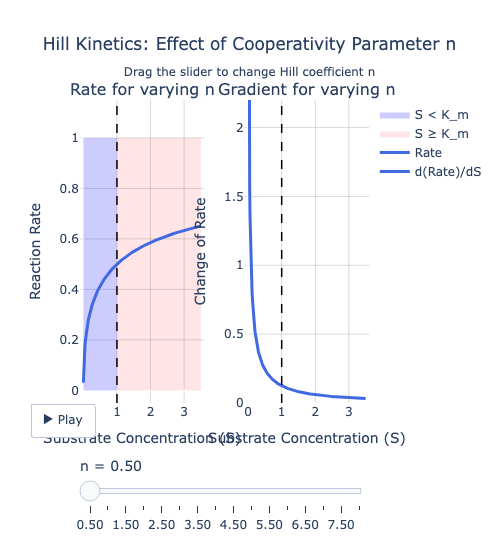

In [20]:
from plotly.subplots import make_subplots

# S-axis grids: a fine grid for evaluating the rate/derivative curves, and
# two sub-ranges (left/right of K_m=1) used only to draw the shaded
# "S < K_m" / "S >= K_m" background regions.
S_values = np.linspace(0.001, 3.5, 300)
S_left   = np.linspace(0, 1,   100)
S_right  = np.linspace(1, 3.5, 150)

# The sequence of Hill coefficients n that the animation steps through.
n_animation = np.linspace(0.5, 8.0, 16)

# ── subplots ──────────────────────────────────────────────────────────────────
# Two panels side by side: rate(S) on the left, d(rate)/dS on the right.
fig_animation = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Rate for varying n', 'Gradient for varying n'),
    horizontal_spacing=0.14
)

# ── trace 0: blue fill S < K_m (left subplot) ─────────────────────────────────
fig_animation.add_trace(go.Scatter(
    x=np.concatenate([S_left, S_left[::-1]]),
    y=np.concatenate([np.ones(100), np.zeros(100)]),
    fill='toself',
    fillcolor='rgba(0,0,255,0.2)',
    line=dict(color='rgba(0,0,0,0)'),
    name='S < K_m',
    hoverinfo='skip'
), row=1, col=1)

# ── trace 1: red fill S >= K_m (left subplot) ──────────────────────────────────
fig_animation.add_trace(go.Scatter(
    x=np.concatenate([S_right, S_right[::-1]]),
    y=np.concatenate([np.ones(150), np.zeros(150)]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.1)',
    line=dict(color='rgba(0,0,0,0)'),
    name='S ≥ K_m',
    hoverinfo='skip'
), row=1, col=1)

# ── trace 2: animated Hill function (left subplot) ───────────────────────────
# Initialise both animated traces at the first value of n; the frames
# below then update these traces as n is varied via the slider/play button.
n_init    = n_animation[0]
rate_init = hill_kinetics(S_values, k_max, K_m, n_init)
deriv_init = np.gradient(rate_init, S_values)

fig_animation.add_trace(go.Scatter(
    x=S_values, y=rate_init,
    mode='lines',
    line=dict(color=n_to_plotly_color(n_init), width=3),
    name='Rate'
), row=1, col=1)

# ── trace 3: animated derivative (right subplot) ──────────────────────────────
fig_animation.add_trace(go.Scatter(
    x=S_values, y=deriv_init,
    mode='lines',
    line=dict(color=n_to_plotly_color(n_init), width=3),
    name='d(Rate)/dS'
), row=1, col=2)

# ── frames: update traces 2 & 3 together ─────────────────────────────────────
# One animation frame per value of n: recompute the rate and its
# derivative, and update traces 2 (rate) and 3 (derivative) with the new
# curves and matching colour.
frames = []
for n_val in n_animation:
    rate  = hill_kinetics(S_values, k_max, K_m, n_val)
    deriv = np.gradient(rate, S_values)
    frames.append(go.Frame(
        data=[
            go.Scatter(x=S_values, y=rate,  mode='lines', line=dict(color=n_to_plotly_color(n_val), width=3)),
            go.Scatter(x=S_values, y=deriv, mode='lines', line=dict(color=n_to_plotly_color(n_val), width=3))
        ],
        traces=[2, 3],
        name=f"n={n_val:.2f}"
    ))

fig_animation.frames = frames

# ── layout ────────────────────────────────────────────────────────────────────
fig_animation.update_layout(
    title=dict(
        text="Hill Kinetics: Effect of Cooperativity Parameter n"
             "<br><sub>Drag the slider to change Hill coefficient n</sub>",
        x=0.5
    ),
    width=1050,
    height=540,
    plot_bgcolor='white',
    legend=dict(x=1.02, y=1, xanchor='left'),
    # Dashed vertical lines marking S=K_m=1 in both panels
    shapes=[
        dict(type='line', x0=1, x1=1, y0=0, y1=1,
             xref='x',  yref='y domain',
             line=dict(color='black', dash='dash', width=1.5)),
        dict(type='line', x0=1, x1=1, y0=0, y1=1,
             xref='x2', yref='y2 domain',
             line=dict(color='black', dash='dash', width=1.5)),
    ],
    # Play button: steps through all frames (i.e. all values of n)
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=0,
        x=0.05,
        xanchor='right',
        buttons=[dict(
            label='▶ Play',
            method='animate',
            args=[None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}]
        )]
    )],
    # Slider: lets the user jump directly to a given value of n
    sliders=[dict(
        currentvalue=dict(prefix='n = ', font=dict(size=14)),
        pad=dict(t=50),
        steps=[dict(
            method='animate',
            args=[[f"n={n_val:.2f}"],
                  {'mode': 'immediate',
                   'frame': {'duration': 100, 'redraw': True},
                   'transition': {'duration': 0}}],
            label=f"{n_val:.2f}"
        ) for n_val in n_animation]
    )]
)

# axes styling to match static plot
grid_style = dict(gridcolor='rgba(0,0,0,0.15)', showgrid=True, gridwidth=1)

fig_animation.update_xaxes(title_text='Substrate Concentration (S)',
                            range=[-0.1, 3.6], **grid_style, row=1, col=1)
fig_animation.update_xaxes(title_text='Substrate Concentration (S)',
                            range=[-0.1, 3.6], **grid_style, row=1, col=2)
fig_animation.update_yaxes(title_text='Reaction Rate',
                            range=[-0.05, 1.15], **grid_style, row=1, col=1)
fig_animation.update_yaxes(title_text='Change of Rate',
                            range=[0, 2.2], **grid_style, row=1, col=2)

fig_animation.show()

The animation shows the function at different values of $n$. You can either play the animation or move the slider at the bottom. Test the shapes at different value of $n$. The colours roughly correspond to the colours used in the above plot with three values of $n$. The change of the rate on the right-hand side updates simultaneously with the change in $n$. For values  of $n$ smaller than 1, the range in which the rate increases strongly shrinks. 

The Hill function is a basic model and detailed descriptions of enzymatic rates build on this to much more complex mechanisms of cooperativity. However, detailed models have more than 3 constant parameters and in practice these values are simply not known under in vivo conditions. Thus one can always start with basic functions and introduce complexity as is required by experimental findings. 

The next section will use this function in the construction of a dynamic model of an enzymatic reaction under open-flow conditions. 

## Summary and outlook

This notebook introduced the Michaelis-Menten and Hill rate laws as static functions of substrate concentration $S$:

$$\text{rate}(S) = \frac{k_{max}\,S^n}{K_m^{\,n} + S^n}$$

- For $n=1$, this is the classic hyperbolic Michaelis-Menten curve: a smooth, monotonic approach to $V_{max}$.
- For $n>1$, the curve becomes sigmoidal, with an inflection point near $S=K_m$. As $n$ increases, the transition becomes sharper, and the rate function approaches a step ("switch") between low and high values.
- The two-dimensional rate and gradient landscapes show how this hyperbolic-to-sigmoidal transition unfolds continuously as $n$ is varied, and where the rate of change of the rate (the gradient) is largest.

**Outlook.** The rate law studied here describes *activation*: the reaction speeds up monotonically with $S$. Notebook *02_forward_inhibition_analysis* adds a second, inhibitory term to this same Hill-type expression — so that the rate law becomes non-monotonic ("bell-shaped"), rising and then falling again as $S$ increases. Embedding this non-monotonic rate law in an open-flow system (constant influx and linear removal of $S$) is enough to create **multiple steady states** (bistability), visualised there as a 1D and then 2D potential ("Waddington") landscape. Notebook *03_enzyme_oscillations* takes the next step, replacing the instantaneous inhibition with a *delayed* feedback loop between two coupled species — turning the steady states of notebook 02 into sustained **oscillations**.

In short: the sigmoidal nonlinearity introduced here by the Hill coefficient $n$ is the basic nonlinear "switch" element that, once embedded in feedback loops with the right structure, gives rise to both multistability and oscillations.

## References and further reading

Many more mathematical details are available on the Wikipedia entries for [the Michaelis-Menten](https://en.wikipedia.org/wiki/Michaelis%E2%80%93Menten_kinetics) and for [the Hill equation](https://en.wikipedia.org/wiki/Hill_equation_(biochemistry)). 

- Henri, V. (1903). *Lois Générales de l'Action des Diastases*. Hermann, Paris. — early formulation of enzyme saturation kinetics via an intermediate enzyme-substrate complex.
- Michaelis, L., Menten, M.L. (1913). Die Kinetik der Invertinwirkung. *Biochemische Zeitschrift*, 49, 333–369. — the original Michaelis-Menten paper. Here is [an English translation](https://pubs.acs.org/doi/10.1021/bi201284u). 
- Hill, A.V. (1910). The possible effects of the aggregation of the molecules of haemoglobin on its dissociation curves. *Journal of Physiology*, 40, iv-vii. — the original Hill equation, derived for oxygen binding to haemoglobin.
- Koshland, D.E., Némethy, G., Filmer, D. (1966). Comparative aspects of allosteric models for cooperative interactions. *Biochemistry*, 5(1), 365–385. — overview of explicit cooperative-binding models, including the MWC model referenced above as an alternative to the Hill equation.
- Alon, U. (2006). *An Introduction to Systems Biology: Design Principles of Biological Circuits*. Chapman & Hall/CRC. — accessible introduction to Hill-function based models of gene regulation, used throughout the "computational modelling" examples above.

## A more complex Example: Plot of the MWC Rate Function

The **Monod-Wyman-Changeux (MWC)** model describes cooperative enzymes that exist in two conformational states: a high-affinity **R** (relaxed) state and a low-affinity **T** (tense) state. The allosteric constant $L = [T_0]/[R_0]$ sets the T-to-R equilibrium in the absence of ligand.

Defining the normalised ligand concentration $\alpha = [S]/K_R$ and the ratio of dissociation constants $c = K_R/K_T$ (with $0 < c < 1$ because R binds more tightly), the **fractional saturation** of the binding sites is:

$$\bar{Y} = \frac{\alpha(1+\alpha)^{n-1} + Lc\alpha(1+c\alpha)^{n-1}}{(1+\alpha)^n + L(1+c\alpha)^n}$$

and the **fraction of proteins in the R state** is:

$$\bar{R} = \frac{(1+\alpha)^n}{(1+\alpha)^n + L(1+c\alpha)^n}$$

Going from $\bar{Y}$ to a **reaction rate** follows the same logic as Michaelis-Menten: $\bar{Y}$ is the fraction of binding sites occupied, so at full saturation $v = k_{max}$, and in general:

$$v = k_{max}\,\bar{Y}$$

In [21]:
def mwc_kinetics(S, k_max, K_R, L, c, n):
    """
    Monod-Wyman-Changeux (MWC) kinetics.
    Rate is k_max scaled by the fractional saturation Y_bar.

    S:     substrate/ligand concentration (scalar or array)
    k_max: maximum reaction rate (achieved when all sites are occupied)
    K_R:   dissociation constant for the R (high-affinity) state
    L:     allosteric constant  L = [T0]/[R0]  (unliganded T-to-R ratio)
    c:     ratio of dissociation constants  c = K_R / K_T  (0 < c < 1)
    n:     number of binding sites (subunits)
    """

    alpha = S / K_R

    # Fractional saturation of binding sites
    Y_bar = (alpha * (1 + alpha)**(n - 1) + L * c * alpha * (1 + c * alpha)**(n - 1)) / \
            ((1 + alpha)**n + L * (1 + c * alpha)**n)

    # Fraction of proteins in the R state
    R_bar = (1 + alpha)**n / ((1 + alpha)**n + L * (1 + c * alpha)**n)

    rate = k_max * Y_bar

    return rate, Y_bar, R_bar


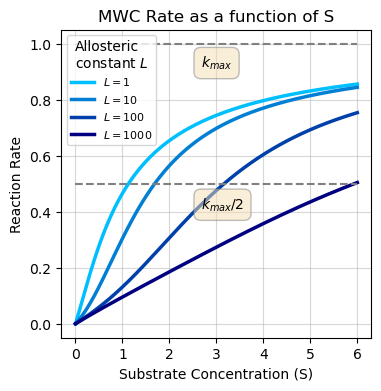

In [22]:
# Constants
K_R      = 1          # dissociation constant for R state
k_max    = 1          # maximum rate
c        = 0.1        # c = K_R / K_T  (T state has 10x weaker affinity)
n        = 4          # number of subunits / binding sites
L_values = [1, 10, 100, 1000]   # allosteric constants to compare

# Range of substrate values
S_min, S_max = 0, 6
values = 200
S_vals = np.linspace(S_min, S_max, values)

# Custom colour map: low L -> light blue, high L -> dark blue
cmap   = LinearSegmentedColormap.from_list("mwc", ["deepskyblue", "navy"])
colors = [cmap(i / (len(L_values) - 1)) for i in range(len(L_values))]


# --- Plot: MWC rate for varying L ---
fig = figure(figsize=(4, 4))
ax1 = fig.add_subplot()

for L, col in zip(L_values, colors):
    rate, Y_bar, R_bar = mwc_kinetics(S_vals, k_max, K_R, L, c, n)
    ax1.plot(S_vals, rate, color=col, linewidth=2.5, label=f"$L={L}$")

ax1.hlines(k_max,     0, S_max, "gray", linestyles="dashed")
ax1.hlines(k_max / 2, 0, S_max, "gray", linestyles="dashed")

ax1.set_xlabel("Substrate Concentration (S)")
ax1.set_ylabel("Reaction Rate")
ax1.set_title("MWC Rate as a function of S")
ax1.grid(True, alpha=0.5)
ax1.legend(title="Allosteric\nconstant $L$", fontsize=8)


# Textbox: k_max
props = dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.5, edgecolor="gray")
ax1.text(
    0.45, 0.92, "$k_{max}$",
    transform=ax1.transAxes, fontsize=10,
    verticalalignment="top", bbox=props
)

# Textbox: k_max / 2
ax1.text(
    0.45, 0.46, "$k_{max}/2$",
    transform=ax1.transAxes, fontsize=10,
    verticalalignment="top", bbox=props
);


The key to understand the relationship with the Michaelis-Menten function is that Y̅ and the Michaelis-Menten saturation term [S]/(K_m + [S]) are both fractional occupancies — they tell you what fraction of binding sites are occupied at a given [S]. Multiplying by k_max (the rate at full occupancy) gives the rate at any concentration of [S]. The MWC model gives a richer expression for that fraction, driven by the ligand-dependent allosteric equilibrium between the relaxed R and tense T states
